# 📊 Notebook 01 - Coleta e Exploração de Dados

## Tech Challenge 4 - LSTM VALE3

---

### Objetivos deste Notebook:

1. **Baixar dados históricos** da VALE3 usando yfinance
2. **Explorar os dados** (EDA - Exploratory Data Analysis)
3. **Entender padrões** e características da série temporal
4. **Preparar insights** para a modelagem

---

### Por que fazer EDA antes de modelar?

Muitos iniciantes pulam direto para o modelo, mas isso é um erro! A análise exploratória nos ajuda a:

- Entender a **distribuição** dos dados
- Identificar **outliers** e anomalias
- Detectar **tendências** e **sazonalidade**
- Verificar **dados faltantes**
- Escolher a **janela temporal** adequada
- Ter **intuição** sobre o problema

Um modelo é tão bom quanto os dados que recebe!

## 1. Setup do Ambiente

In [1]:
# =============================================================================
# IMPORTS
# =============================================================================

# Manipulação de dados
import pandas as pd
import numpy as np

# Coleta de dados financeiros
import yfinance as yf

# Visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Datas
from datetime import datetime, timedelta

# Configurações de visualização
plt.style.use('seaborn-v0_8-whitegrid')  # Estilo limpo e profissional
plt.rcParams['figure.figsize'] = (14, 6)  # Tamanho padrão dos gráficos
plt.rcParams['font.size'] = 12

# Warnings
import warnings
warnings.filterwarnings('ignore')

print("✓ Bibliotecas importadas com sucesso!")

✓ Bibliotecas importadas com sucesso!


## 2. Coleta de Dados

### Sobre o yfinance

O `yfinance` é uma biblioteca Python que permite acessar dados do Yahoo Finance de forma simples. Ele retorna dados no formato OHLCV:

| Coluna | Significado | Descrição |
|--------|-------------|------------|
| **Open** | Abertura | Primeiro preço negociado no dia |
| **High** | Máxima | Maior preço atingido no dia |
| **Low** | Mínima | Menor preço atingido no dia |
| **Close** | Fechamento | Último preço negociado no dia |
| **Volume** | Volume | Quantidade de ações negociadas |

### Por que usamos o preço de Fechamento (Close)?

O preço de fechamento é o mais usado em análises porque:
- Representa o **consenso final** do mercado naquele dia
- É usado para calcular **índices** e **benchmarks**
- Serve de referência para **abertura** do próximo dia

In [2]:
# =============================================================================
# CONFIGURAÇÕES
# =============================================================================

TICKER = 'VALE3.SA'  # Código da Vale na B3 (sufixo .SA para ações brasileiras)
PERIODO_ANOS = 5      # Baixar 5 anos de histórico

# Calcula as datas
data_fim = datetime.now()
data_inicio = data_fim - timedelta(days=PERIODO_ANOS * 365)

print(f"Ticker: {TICKER}")
print(f"Período: {data_inicio.strftime('%Y-%m-%d')} até {data_fim.strftime('%Y-%m-%d')}")
print(f"Aproximadamente {PERIODO_ANOS} anos de dados")

Ticker: VALE3.SA
Período: 2021-01-23 até 2026-01-22
Aproximadamente 5 anos de dados


In [3]:
# =============================================================================
# DOWNLOAD DOS DADOS
# =============================================================================

print(f"Baixando dados de {TICKER}...")

# O yfinance.download() é a função principal para baixar dados
df = yf.download(
    tickers=TICKER,
    start=data_inicio.strftime('%Y-%m-%d'),
    end=data_fim.strftime('%Y-%m-%d'),
    progress=True  # Mostra barra de progresso
)

# -----------------------------------------------------------------------------
# IMPORTANTE: Tratamento do MultiIndex
# -----------------------------------------------------------------------------
# Versões recentes do yfinance (>=0.2.x) retornam colunas com MultiIndex quando
# você baixa apenas 1 ticker: ('Close', 'VALE3.SA') em vez de apenas 'Close'
# 
# Isso causa erros como:
#   TypeError: unsupported format string passed to Series.__format__
#
# A solução é "achatar" o MultiIndex para ter apenas o nome da coluna:

if isinstance(df.columns, pd.MultiIndex):
    # Pega apenas o primeiro nível (Open, High, Low, Close, Volume)
    df.columns = df.columns.get_level_values(0)
    print("\n⚠️  Detectado MultiIndex nas colunas - corrigido automaticamente!")

print(f"\n✓ Download concluído!")
print(f"  Total de registros: {len(df)}")
print(f"  Colunas: {list(df.columns)}")
print(f"  Período real: {df.index.min().strftime('%Y-%m-%d')} até {df.index.max().strftime('%Y-%m-%d')}")

Baixando dados de VALE3.SA...


[*********************100%***********************]  1 of 1 completed


⚠️  Detectado MultiIndex nas colunas - corrigido automaticamente!

✓ Download concluído!
  Total de registros: 1245
  Colunas: ['Close', 'High', 'Low', 'Open', 'Volume']
  Período real: 2021-01-26 até 2026-01-21


In [4]:
# =============================================================================
# SALVANDO DADOS BRUTOS
# =============================================================================

# Criar pasta se não existir
import os
os.makedirs('../data/raw', exist_ok=True)

# Salvar em CSV
caminho_csv = '../data/raw/vale3_sa.csv'
df.to_csv(caminho_csv)

print(f"✓ Dados salvos em: {caminho_csv}")

✓ Dados salvos em: ../data/raw/vale3_sa.csv


## 3. Primeira Olhada nos Dados

Agora vamos explorar a estrutura dos dados baixados.

In [5]:
# =============================================================================
# ESTRUTURA DOS DADOS
# =============================================================================

print("INFORMAÇÕES DO DATAFRAME")
print("=" * 50)
print(df.info())

INFORMAÇÕES DO DATAFRAME
<class 'pandas.DataFrame'>
DatetimeIndex: 1245 entries, 2021-01-26 to 2026-01-21
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   1245 non-null   float64
 1   High    1245 non-null   float64
 2   Low     1245 non-null   float64
 3   Open    1245 non-null   float64
 4   Volume  1245 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 58.4 KB
None


In [6]:
# Primeiros registros
print("\nPRIMEIROS 5 REGISTROS (mais antigos):")
df.head()


PRIMEIROS 5 REGISTROS (mais antigos):


Price,Close,High,Low,Open,Volume
Date,,,,,
2021-01-26,53.027027,54.419892,52.801626,53.743685,24921600
2021-01-27,51.553253,52.697599,50.975302,52.241017,32419700
2021-01-28,52.651367,52.795855,50.917513,50.975307,35900800
2021-01-29,50.830822,52.506882,50.738352,52.009843,31481600
2021-02-01,52.749615,52.749615,51.194929,52.021399,27135500


In [9]:
# Últimos registros
print("\nÚLTIMOS 5 REGISTROS (mais recentes):")
df.tail()


ÚLTIMOS 5 REGISTROS (mais recentes):


Price,Close,High,Low,Open,Volume
Date,,,,,
2026-01-15,78.849998,79.639999,78.510002,78.900002,35503900
2026-01-16,78.879997,78.879997,77.570000,78.389999,45910100
2026-01-19,78.570000,78.650002,77.870003,78.519997,10678500
2026-01-20,80.080002,80.209999,77.410004,77.830002,31198500
2026-01-21,82.500000,82.800003,80.500000,80.989998,83134600


In [14]:
# =============================================================================
# ESTATÍSTICAS DESCRITIVAS
# =============================================================================

print("ESTATÍSTICAS DESCRITIVAS")
print("=" * 50)
print("\nEssas estatísticas nos dão uma visão geral dos dados:")
print("- count: número de registros (dias de negociação)")
print("- mean: média dos valores")
print("- std: desvio padrão (volatilidade)")
print("- min/max: valores extremos")
print("- 25%/50%/75%: quartis (distribuição)")
print()

df.describe().round(2)

ESTATÍSTICAS DESCRITIVAS

Essas estatísticas nos dão uma visão geral dos dados:
- count: número de registros (dias de negociação)
- mean: média dos valores
- std: desvio padrão (volatilidade)
- min/max: valores extremos
- 25%/50%/75%: quartis (distribuição)



Price,Close,High,Low,Open,Volume
count,1245.00,1245.00,1245.00,1245.00,1.245000e+03
mean,56.09,56.72,55.51,56.14,2.615319e+07
std,6.94,7.00,6.82,6.90,1.266797e+07
min,42.38,43.96,42.05,43.02,0.000000e+00
25%,50.95,51.55,50.60,51.00,1.828990e+07
50%,53.81,54.43,53.29,53.82,2.316050e+07
75%,60.52,61.35,59.93,60.63,3.148160e+07
max,82.50,82.80,80.50,80.99,2.202628e+08


## 4. Verificação de Dados Faltantes

### Por que isso é importante?

Dados faltantes podem causar:
- Erros no treinamento do modelo
- Viés nos resultados
- Sequências quebradas (grave para LSTM!)

Em dados financeiros, dados faltantes geralmente indicam:
- Feriados (bolsa fechada)
- Fins de semana
- Problemas técnicos na coleta

In [12]:
# =============================================================================
# VERIFICAÇÃO DE DADOS FALTANTES
# =============================================================================

print("DADOS FALTANTES POR COLUNA")
print("=" * 50)

dados_faltantes = df.isnull().sum()
percentual_faltante = (df.isnull().sum() / len(df) * 100).round(2)

resumo_faltantes = pd.DataFrame({
    'Faltantes': dados_faltantes,
    'Percentual (%)': percentual_faltante
})

print(resumo_faltantes)

if dados_faltantes.sum() == 0:
    print("\n✓ Nenhum dado faltante encontrado!")
else:
    print(f"\n⚠️ Encontrados {dados_faltantes.sum()} valores faltantes")

DADOS FALTANTES POR COLUNA
        Faltantes  Percentual (%)
Price                            
Close           0             0.0
High            0             0.0
Low             0             0.0
Open            0             0.0
Volume          0             0.0

✓ Nenhum dado faltante encontrado!


## 5. Visualização dos Dados

### A importância de visualizar

Gráficos nos ajudam a identificar:
- **Tendências**: o preço está subindo ou caindo ao longo do tempo?
- **Sazonalidade**: existem padrões que se repetem?
- **Volatilidade**: períodos de maior instabilidade
- **Outliers**: valores extremos que podem afetar o modelo

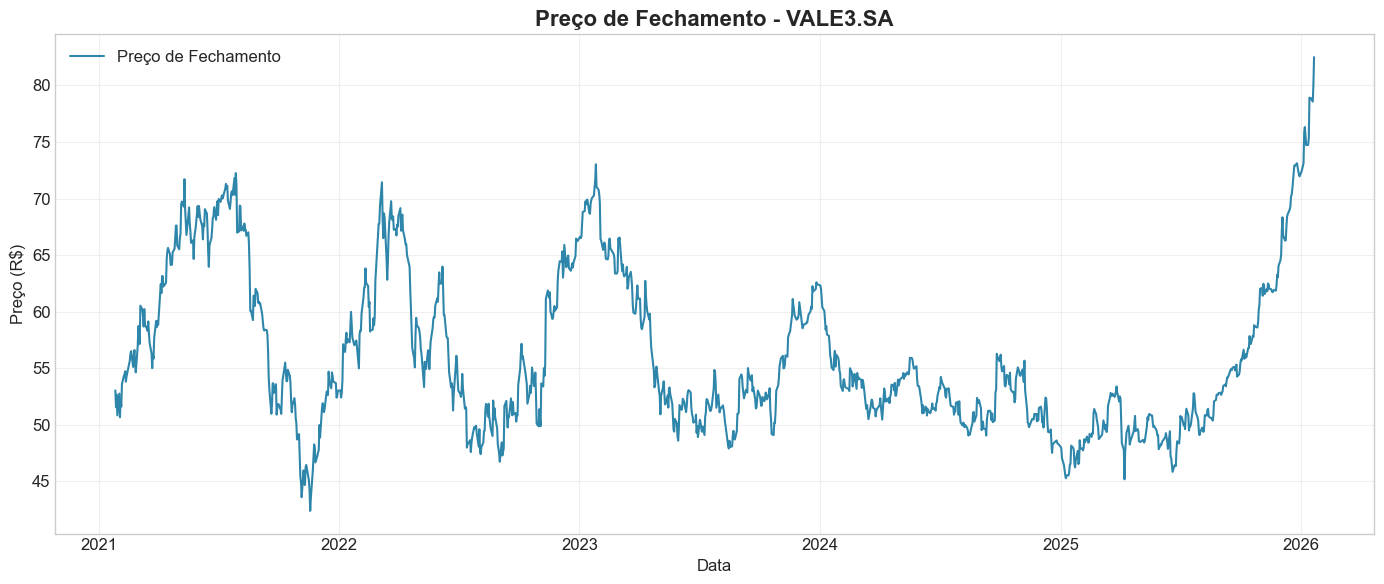


📈 ANÁLISE DO GRÁFICO:
   Preço mínimo: R$ 42.38
   Preço máximo: R$ 82.50
   Variação total: 55.6%


In [13]:
# =============================================================================
# GRÁFICO 1: PREÇO DE FECHAMENTO AO LONGO DO TEMPO
# =============================================================================

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df.index, df['Close'], color='#2E86AB', linewidth=1.5, label='Preço de Fechamento')

ax.set_title(f'Preço de Fechamento - {TICKER}', fontsize=16, fontweight='bold')
ax.set_xlabel('Data', fontsize=12)
ax.set_ylabel('Preço (R$)', fontsize=12)
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Estatísticas usando float() para extrair valor escalar
preco_min = float(df['Close'].min())
preco_max = float(df['Close'].max())
preco_primeiro = float(df['Close'].iloc[0])
preco_ultimo = float(df['Close'].iloc[-1])

print("\n📈 ANÁLISE DO GRÁFICO:")
print(f"   Preço mínimo: R$ {preco_min:.2f}")
print(f"   Preço máximo: R$ {preco_max:.2f}")
print(f"   Variação total: {((preco_ultimo / preco_primeiro) - 1) * 100:.1f}%")

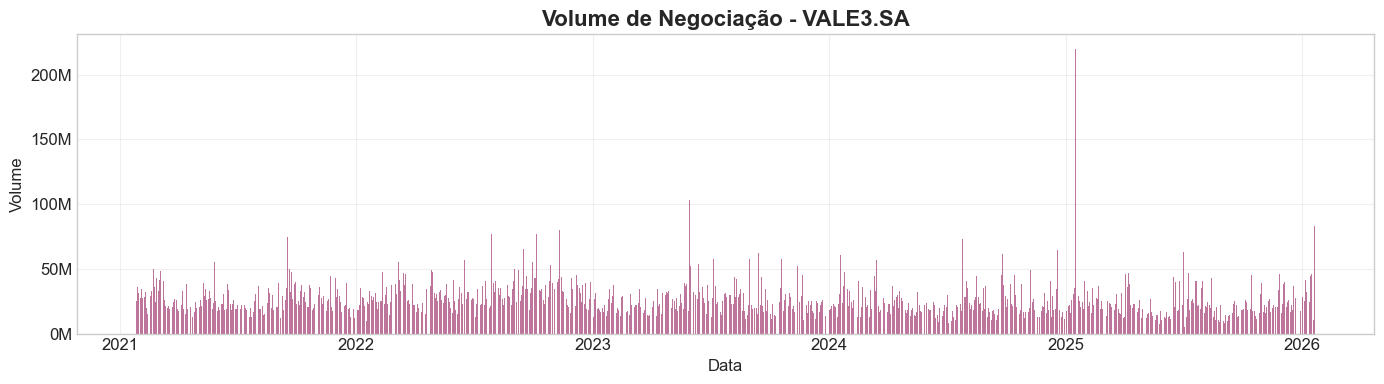


📊 ANÁLISE DO VOLUME:
   Volume médio diário: 26.15 milhões de ações
   Volume máximo: 220.26 milhões de ações


In [15]:
# =============================================================================
# GRÁFICO 2: VOLUME DE NEGOCIAÇÃO
# =============================================================================

fig, ax = plt.subplots(figsize=(14, 4))

ax.bar(df.index, df['Volume'], color='#A23B72', alpha=0.7, width=1)

ax.set_title(f'Volume de Negociação - {TICKER}', fontsize=16, fontweight='bold')
ax.set_xlabel('Data', fontsize=12)
ax.set_ylabel('Volume', fontsize=12)
ax.grid(True, alpha=0.3)

# Formata eixo Y para milhões
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x/1e6:.0f}M'))

plt.tight_layout()
plt.show()

vol_medio = float(df['Volume'].mean())
vol_max = float(df['Volume'].max())

print("\n📊 ANÁLISE DO VOLUME:")
print(f"   Volume médio diário: {vol_medio/1e6:.2f} milhões de ações")
print(f"   Volume máximo: {vol_max/1e6:.2f} milhões de ações")

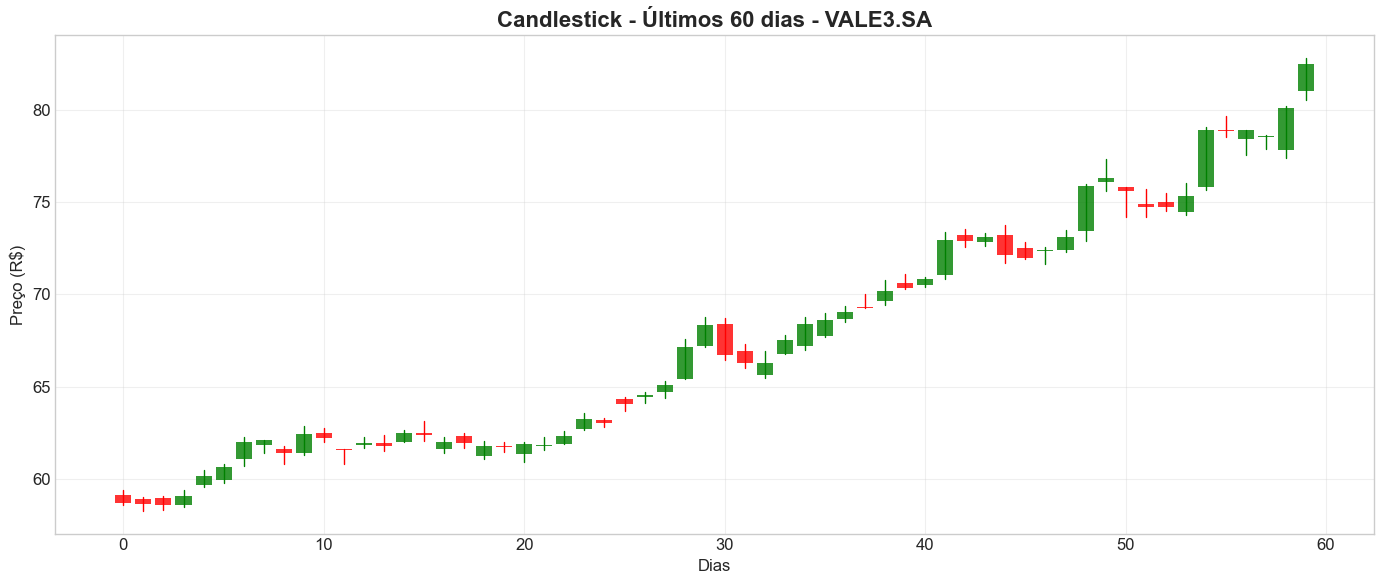


🕯️ SOBRE O CANDLESTICK:
   Verde: dia de alta (fechou acima da abertura)
   Vermelho: dia de baixa (fechou abaixo da abertura)
   Linha vertical: variação entre mínima e máxima do dia


In [16]:
# =============================================================================
# GRÁFICO 3: CANDLESTICK SIMPLIFICADO (OHLC)
# =============================================================================

# Vamos mostrar apenas os últimos 60 dias para melhor visualização
df_recente = df.tail(60).copy()

fig, ax = plt.subplots(figsize=(14, 6))

# Cores: verde para alta, vermelho para baixa
cores = ['green' if float(close) >= float(open_) else 'red' 
         for open_, close in zip(df_recente['Open'], df_recente['Close'])]

# Plota as "velas"
for i, (idx, row) in enumerate(df_recente.iterrows()):
    cor = cores[i]
    # Linha vertical (sombra): Low até High
    ax.plot([i, i], [float(row['Low']), float(row['High'])], color=cor, linewidth=1)
    # Retângulo (corpo): Open até Close
    ax.bar(i, abs(float(row['Close']) - float(row['Open'])), 
           bottom=min(float(row['Open']), float(row['Close'])),
           color=cor, width=0.8, alpha=0.8)

ax.set_title(f'Candlestick - Últimos 60 dias - {TICKER}', fontsize=16, fontweight='bold')
ax.set_xlabel('Dias', fontsize=12)
ax.set_ylabel('Preço (R$)', fontsize=12)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n🕯️ SOBRE O CANDLESTICK:")
print("   Verde: dia de alta (fechou acima da abertura)")
print("   Vermelho: dia de baixa (fechou abaixo da abertura)")
print("   Linha vertical: variação entre mínima e máxima do dia")

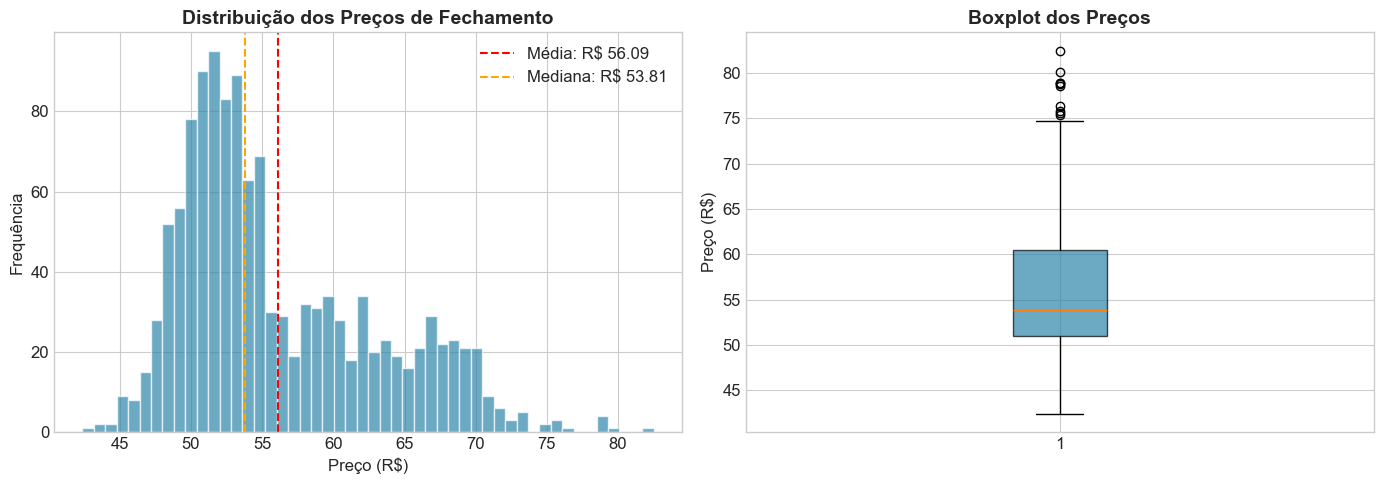


📊 ANÁLISE DA DISTRIBUIÇÃO:
   Média: R$ 56.09
   Mediana: R$ 53.81
   Desvio Padrão: R$ 6.94
   Coeficiente de Variação: 12.4%


In [17]:
# =============================================================================
# GRÁFICO 4: DISTRIBUIÇÃO DOS PREÇOS
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

close_mean = float(df['Close'].mean())
close_median = float(df['Close'].median())

# Histograma
axes[0].hist(df['Close'], bins=50, color='#2E86AB', edgecolor='white', alpha=0.7)
axes[0].axvline(close_mean, color='red', linestyle='--', label=f'Média: R$ {close_mean:.2f}')
axes[0].axvline(close_median, color='orange', linestyle='--', label=f'Mediana: R$ {close_median:.2f}')
axes[0].set_title('Distribuição dos Preços de Fechamento', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Preço (R$)', fontsize=12)
axes[0].set_ylabel('Frequência', fontsize=12)
axes[0].legend()

# Boxplot
bp = axes[1].boxplot(df['Close'].dropna(), patch_artist=True)
bp['boxes'][0].set_facecolor('#2E86AB')
bp['boxes'][0].set_alpha(0.7)
axes[1].set_title('Boxplot dos Preços', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Preço (R$)', fontsize=12)

plt.tight_layout()
plt.show()

close_std = float(df['Close'].std())
cv = (close_std / close_mean) * 100

print("\n📊 ANÁLISE DA DISTRIBUIÇÃO:")
print(f"   Média: R$ {close_mean:.2f}")
print(f"   Mediana: R$ {close_median:.2f}")
print(f"   Desvio Padrão: R$ {close_std:.2f}")
print(f"   Coeficiente de Variação: {cv:.1f}%")

## 6. Análise de Retornos

### Por que analisar retornos em vez de preços?

Os **retornos** (variação percentual) são mais interessantes para análise porque:

1. São **estacionários** (média e variância mais constantes)
2. Permitem **comparar** ativos de preços diferentes
3. Mostram a **volatilidade real** do ativo

**Fórmula do retorno diário:**
```
retorno = (preço_hoje - preço_ontem) / preço_ontem
```

Ou em pandas: `df['Close'].pct_change()`

In [18]:
# =============================================================================
# CÁLCULO DOS RETORNOS
# =============================================================================

# Calcula retorno diário
df['Retorno'] = df['Close'].pct_change()

# Remove o primeiro valor (NaN)
retornos = df['Retorno'].dropna()

ret_mean = float(retornos.mean())
ret_std = float(retornos.std())
ret_max = float(retornos.max())
ret_min = float(retornos.min())

print("ESTATÍSTICAS DOS RETORNOS DIÁRIOS")
print("=" * 50)
print(f"Retorno médio diário: {ret_mean * 100:.4f}%")
print(f"Retorno médio anualizado: {ret_mean * 252 * 100:.2f}%")  # 252 dias úteis
print(f"Volatilidade diária: {ret_std * 100:.2f}%")
print(f"Volatilidade anualizada: {ret_std * np.sqrt(252) * 100:.2f}%")
print(f"\nMaior ganho em um dia: +{ret_max * 100:.2f}%")
print(f"Maior perda em um dia: {ret_min * 100:.2f}%")

ESTATÍSTICAS DOS RETORNOS DIÁRIOS
Retorno médio diário: 0.0529%
Retorno médio anualizado: 13.34%
Volatilidade diária: 1.87%
Volatilidade anualizada: 29.70%

Maior ganho em um dia: +10.40%
Maior perda em um dia: -7.59%


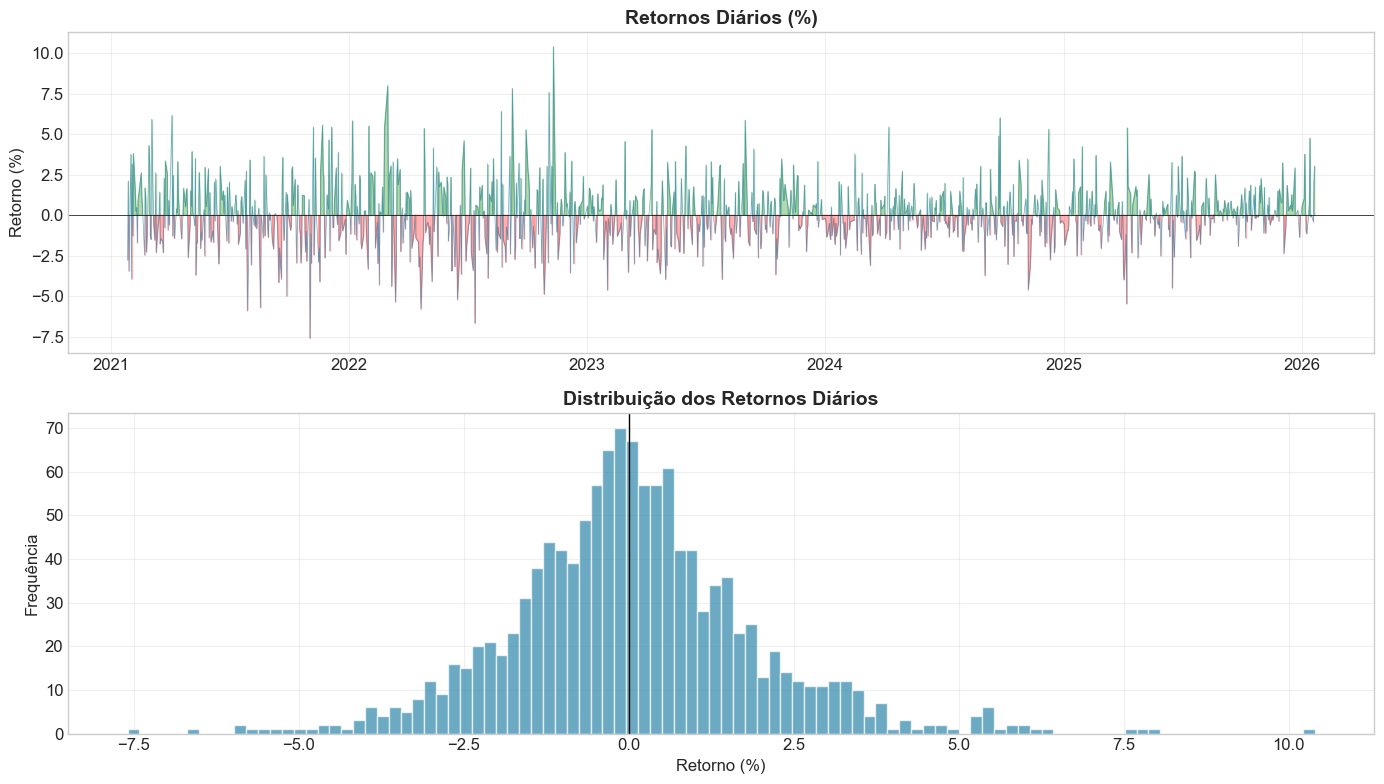


📈 OBSERVAÇÕES:
   - Os retornos se concentram próximos de 0 (distribuição aproximadamente normal)
   - Existem 'caudas gordas' (fat tails): eventos extremos mais frequentes que o esperado
   - Isso é típico de mercados financeiros e é importante para gestão de risco


In [19]:
# =============================================================================
# GRÁFICO DE RETORNOS
# =============================================================================

fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# Retornos ao longo do tempo
axes[0].plot(retornos.index, retornos * 100, color='#2E86AB', linewidth=0.5, alpha=0.7)
axes[0].axhline(0, color='black', linestyle='-', linewidth=0.5)
axes[0].fill_between(retornos.index, retornos * 100, 0, 
                     where=(retornos >= 0), color='green', alpha=0.3)
axes[0].fill_between(retornos.index, retornos * 100, 0, 
                     where=(retornos < 0), color='red', alpha=0.3)
axes[0].set_title('Retornos Diários (%)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Retorno (%)', fontsize=12)
axes[0].grid(True, alpha=0.3)

# Histograma dos retornos
axes[1].hist(retornos * 100, bins=100, color='#2E86AB', edgecolor='white', alpha=0.7)
axes[1].axvline(0, color='black', linestyle='-', linewidth=1)
axes[1].set_title('Distribuição dos Retornos Diários', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Retorno (%)', fontsize=12)
axes[1].set_ylabel('Frequência', fontsize=12)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n📈 OBSERVAÇÕES:")
print("   - Os retornos se concentram próximos de 0 (distribuição aproximadamente normal)")
print("   - Existem 'caudas gordas' (fat tails): eventos extremos mais frequentes que o esperado")
print("   - Isso é típico de mercados financeiros e é importante para gestão de risco")

## 7. Análise de Correlação e Autocorrelação

### O que é Autocorrelação?

A **autocorrelação** mede o quanto os valores de uma série temporal se correlacionam com seus valores passados.

- **Autocorrelação alta (lag 1)**: O valor de hoje está muito relacionado ao de ontem
- **Autocorrelação baixa**: Valores passados não ajudam muito a prever o futuro

Para o LSTM funcionar bem, precisamos de **alguma autocorrelação** - senão não há padrão temporal para aprender!

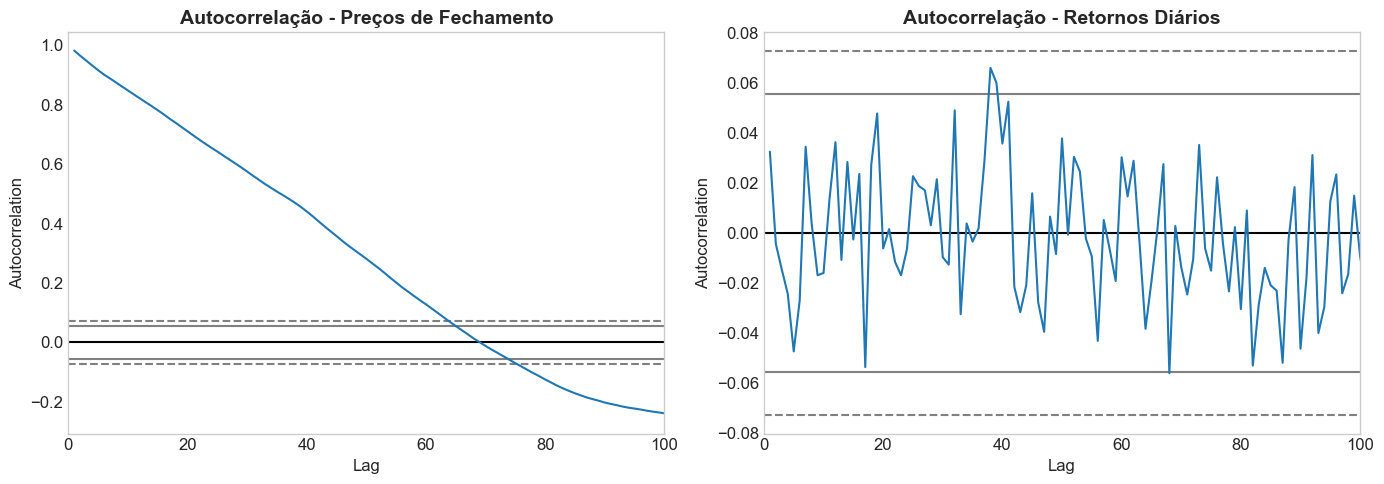


📊 INTERPRETAÇÃO:
   Preços: Alta autocorrelação (linha decai lentamente)
   → Os preços têm 'memória' - bom para LSTM!

   Retornos: Baixa autocorrelação (linha próxima de zero)
   → Retornos são mais difíceis de prever (mercado eficiente)


In [20]:
# =============================================================================
# AUTOCORRELAÇÃO
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Autocorrelação dos preços
pd.plotting.autocorrelation_plot(df['Close'].dropna(), ax=axes[0])
axes[0].set_title('Autocorrelação - Preços de Fechamento', fontsize=14, fontweight='bold')
axes[0].set_xlim([0, 100])

# Autocorrelação dos retornos
pd.plotting.autocorrelation_plot(retornos, ax=axes[1])
axes[1].set_title('Autocorrelação - Retornos Diários', fontsize=14, fontweight='bold')
axes[1].set_xlim([0, 100])

plt.tight_layout()
plt.show()

print("\n📊 INTERPRETAÇÃO:")
print("   Preços: Alta autocorrelação (linha decai lentamente)")
print("   → Os preços têm 'memória' - bom para LSTM!")
print("")
print("   Retornos: Baixa autocorrelação (linha próxima de zero)")
print("   → Retornos são mais difíceis de prever (mercado eficiente)")

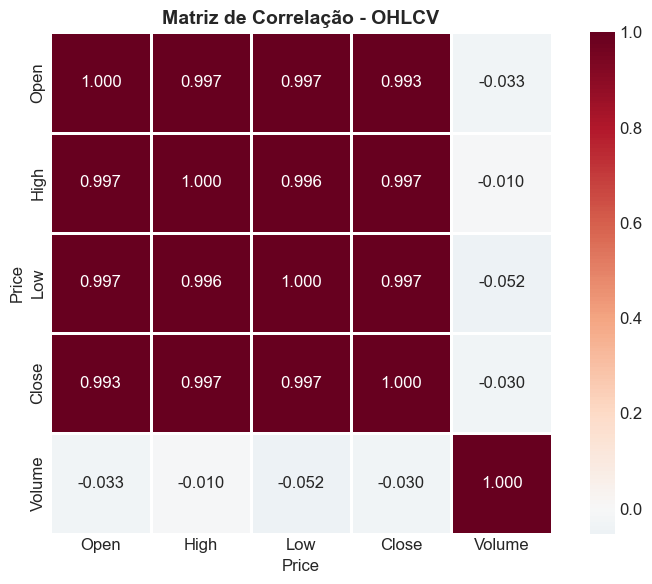


📊 INTERPRETAÇÃO:
   - Open, High, Low e Close são altamente correlacionados (~0.99)
   - Isso faz sentido: são diferentes medidas do mesmo dia
   - Volume tem correlação diferente: pode indicar dias atípicos

   Para nosso modelo LSTM, usaremos apenas 'Close' inicialmente.
   Futuras melhorias podem incluir Volume como feature adicional.


In [21]:
# =============================================================================
# CORRELAÇÃO ENTRE VARIÁVEIS
# =============================================================================

# Matriz de correlação
correlacao = df[['Open', 'High', 'Low', 'Close', 'Volume']].corr()

fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(correlacao, annot=True, cmap='RdBu_r', center=0, 
            square=True, linewidths=1, ax=ax, fmt='.3f')

ax.set_title('Matriz de Correlação - OHLCV', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n📊 INTERPRETAÇÃO:")
print("   - Open, High, Low e Close são altamente correlacionados (~0.99)")
print("   - Isso faz sentido: são diferentes medidas do mesmo dia")
print("   - Volume tem correlação diferente: pode indicar dias atípicos")
print("\n   Para nosso modelo LSTM, usaremos apenas 'Close' inicialmente.")
print("   Futuras melhorias podem incluir Volume como feature adicional.")

## 8. Análise de Tendência e Média Móvel

### O que são Médias Móveis?

A **média móvel** suaviza os dados, reduzindo ruído e destacando tendências:

- **MM curta (20 dias)**: Reage rápido a mudanças, mais ruído
- **MM longa (200 dias)**: Reage devagar, mostra tendência de longo prazo

Cruzamentos de médias móveis são usados como sinais de compra/venda:
- MM curta cruza MM longa **para cima** → Sinal de **alta**
- MM curta cruza MM longa **para baixo** → Sinal de **baixa**

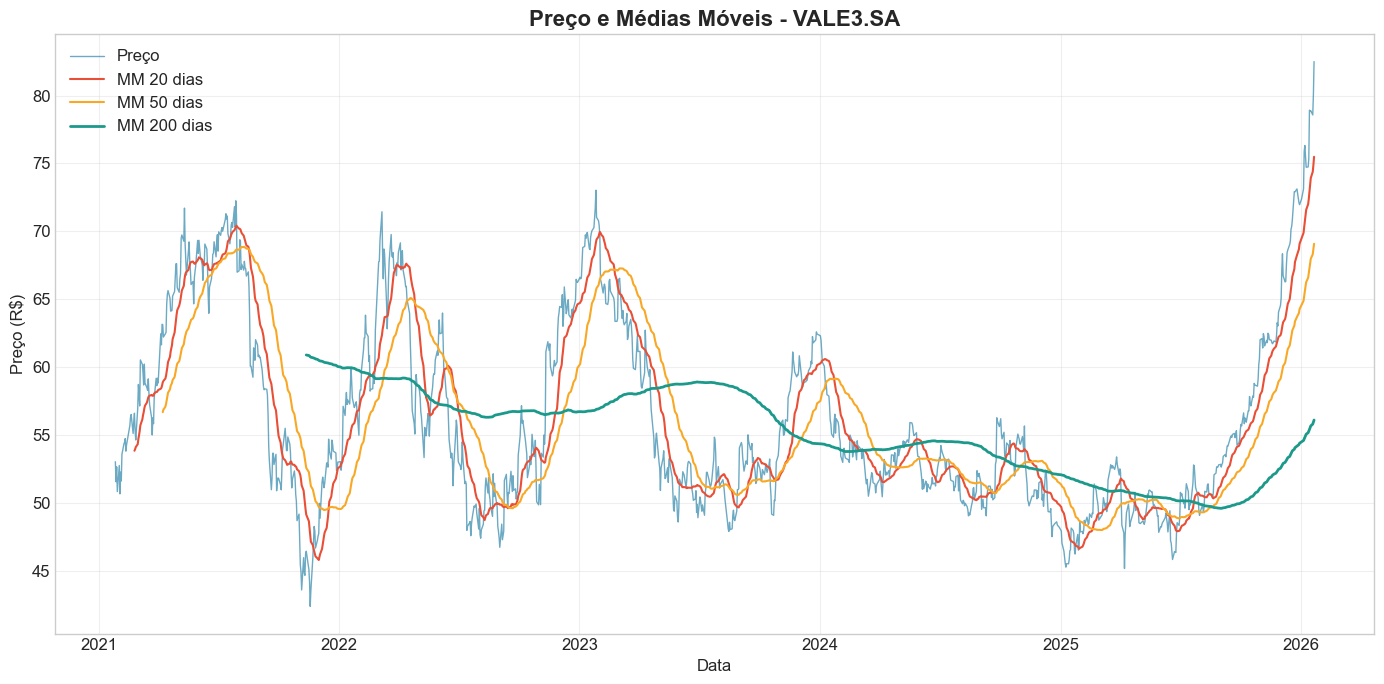


📈 ANÁLISE DE TENDÊNCIA:
   O preço atual (R$ 82.50) está ACIMA da MM200 (R$ 56.10)
   → Tendência de longo prazo: ALTA


In [22]:
# =============================================================================
# MÉDIAS MÓVEIS
# =============================================================================

# Calcula médias móveis
df['MM20'] = df['Close'].rolling(window=20).mean()   # Curto prazo
df['MM50'] = df['Close'].rolling(window=50).mean()   # Médio prazo
df['MM200'] = df['Close'].rolling(window=200).mean() # Longo prazo

# Gráfico
fig, ax = plt.subplots(figsize=(14, 7))

ax.plot(df.index, df['Close'], color='#2E86AB', linewidth=1, label='Preço', alpha=0.7)
ax.plot(df.index, df['MM20'], color='#E94F37', linewidth=1.5, label='MM 20 dias')
ax.plot(df.index, df['MM50'], color='#F9A826', linewidth=1.5, label='MM 50 dias')
ax.plot(df.index, df['MM200'], color='#1B998B', linewidth=2, label='MM 200 dias')

ax.set_title(f'Preço e Médias Móveis - {TICKER}', fontsize=16, fontweight='bold')
ax.set_xlabel('Data', fontsize=12)
ax.set_ylabel('Preço (R$)', fontsize=12)
ax.legend(loc='upper left')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

ultimo_preco = float(df['Close'].iloc[-1])
mm200 = float(df['MM200'].iloc[-1])

print("\n📈 ANÁLISE DE TENDÊNCIA:")
if ultimo_preco > mm200:
    print(f"   O preço atual (R$ {ultimo_preco:.2f}) está ACIMA da MM200 (R$ {mm200:.2f})")
    print("   → Tendência de longo prazo: ALTA")
else:
    print(f"   O preço atual (R$ {ultimo_preco:.2f}) está ABAIXO da MM200 (R$ {mm200:.2f})")
    print("   → Tendência de longo prazo: BAIXA")

## 9. Resumo e Próximos Passos

### O que aprendemos sobre os dados da VALE3?

In [23]:
# =============================================================================
# RESUMO FINAL
# =============================================================================

print("=" * 60)
print("RESUMO DA ANÁLISE EXPLORATÓRIA - VALE3")
print("=" * 60)

print(f"\n📅 PERÍODO ANALISADO:")
print(f"   De: {df.index.min().strftime('%d/%m/%Y')}")
print(f"   Até: {df.index.max().strftime('%d/%m/%Y')}")
print(f"   Total: {len(df)} dias de negociação")

print(f"\n💰 PREÇOS:")
print(f"   Mínimo: R$ {float(df['Close'].min()):.2f}")
print(f"   Máximo: R$ {float(df['Close'].max()):.2f}")
print(f"   Média: R$ {float(df['Close'].mean()):.2f}")
print(f"   Atual: R$ {float(df['Close'].iloc[-1]):.2f}")

print(f"\n📊 VOLATILIDADE:")
print(f"   Diária: {float(retornos.std()) * 100:.2f}%")
print(f"   Anualizada: {float(retornos.std()) * np.sqrt(252) * 100:.1f}%")

print(f"\n✅ QUALIDADE DOS DADOS:")
print(f"   Dados faltantes: {df[['Open', 'High', 'Low', 'Close', 'Volume']].isnull().sum().sum()}")
print(f"   Status: {'Pronto para modelagem!' if df[['Open', 'High', 'Low', 'Close', 'Volume']].isnull().sum().sum() == 0 else 'Requer tratamento'}")

print(f"\n🎯 INSIGHTS PARA O MODELO:")
print(f"   - Alta autocorrelação nos preços → LSTM pode capturar padrões")
print(f"   - Volatilidade moderada → Previsões terão incerteza")
print(f"   - 5 anos de dados → ~{len(df)-60} sequências de 60 dias")

print("\n" + "=" * 60)
print("PRÓXIMO PASSO: Notebook 02 - Preprocessamento")
print("=" * 60)

RESUMO DA ANÁLISE EXPLORATÓRIA - VALE3

📅 PERÍODO ANALISADO:
   De: 26/01/2021
   Até: 21/01/2026
   Total: 1245 dias de negociação

💰 PREÇOS:
   Mínimo: R$ 42.38
   Máximo: R$ 82.50
   Média: R$ 56.09
   Atual: R$ 82.50

📊 VOLATILIDADE:
   Diária: 1.87%
   Anualizada: 29.7%

✅ QUALIDADE DOS DADOS:
   Dados faltantes: 0
   Status: Pronto para modelagem!

🎯 INSIGHTS PARA O MODELO:
   - Alta autocorrelação nos preços → LSTM pode capturar padrões
   - Volatilidade moderada → Previsões terão incerteza
   - 5 anos de dados → ~1185 sequências de 60 dias

PRÓXIMO PASSO: Notebook 02 - Preprocessamento


In [24]:
# =============================================================================
# SALVAR DADOS LIMPOS PARA O PRÓXIMO NOTEBOOK
# =============================================================================

# Remove colunas auxiliares criadas na análise
df_salvar = df[['Open', 'High', 'Low', 'Close', 'Volume']].copy()

# Salva
caminho_limpo = '../data/processed/vale3_clean.csv'
os.makedirs('../data/processed', exist_ok=True)
df_salvar.to_csv(caminho_limpo)

print(f"✓ Dados limpos salvos em: {caminho_limpo}")
print(f"  Shape: {df_salvar.shape}")

✓ Dados limpos salvos em: ../data/processed/vale3_clean.csv
  Shape: (1245, 5)
